In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r'ford.csv')

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [6]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


<Axes: xlabel='price', ylabel='Count'>

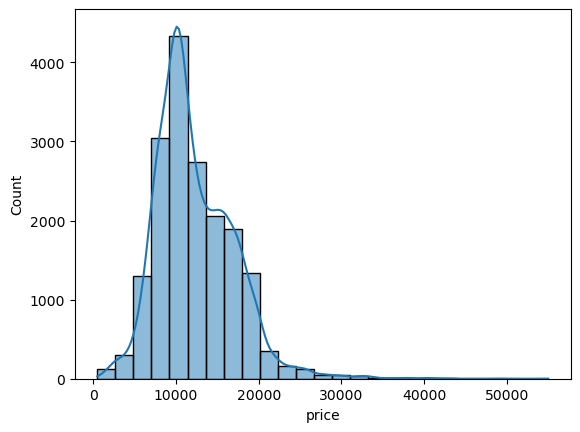

In [9]:
sns.histplot(df['price'] , bins = 25 , kde = True)

<Axes: >

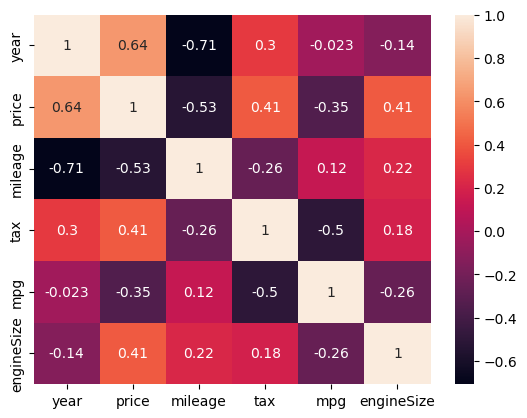

In [11]:
sns.heatmap(df.corr(numeric_only =True) , annot = True)

In [12]:
# From the above heatmap we can see the correlation between year , mileage seeems to be very much with the prices

<Axes: xlabel='year', ylabel='price'>

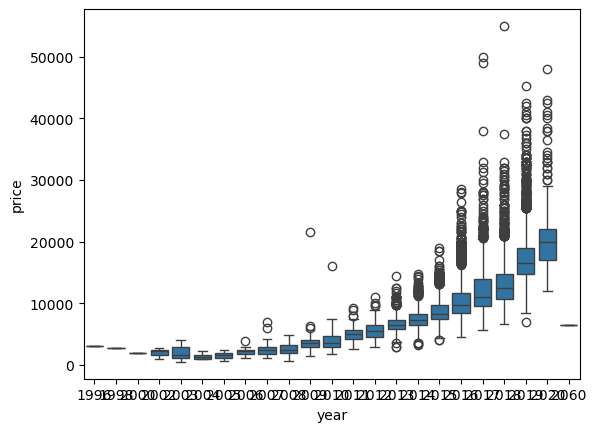

In [13]:
sns.boxplot( data = df , x = 'year' , y = 'price' )

<Axes: xlabel='engineSize', ylabel='price'>

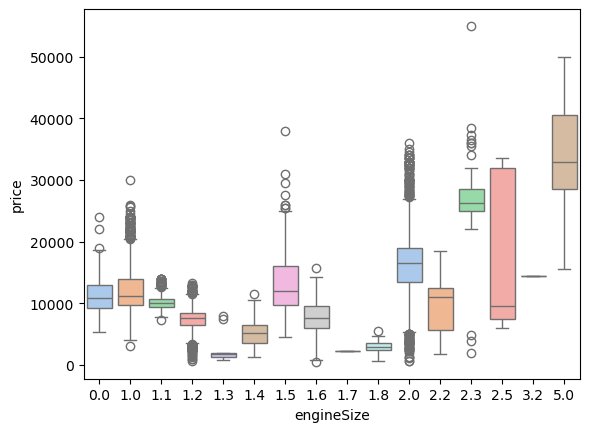

In [15]:
sns.boxplot( data = df , x = 'engineSize' , y = 'price'  , palette = 'pastel')

<Axes: xlabel='transmission', ylabel='price'>

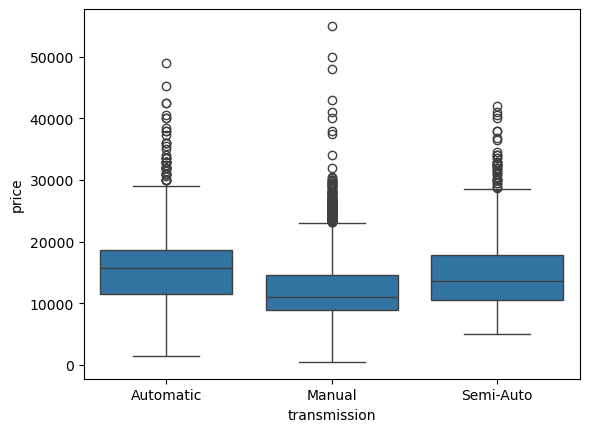

In [16]:
sns.boxplot( data = df , x = 'transmission' , y = 'price'  )

<Axes: xlabel='fuelType', ylabel='price'>

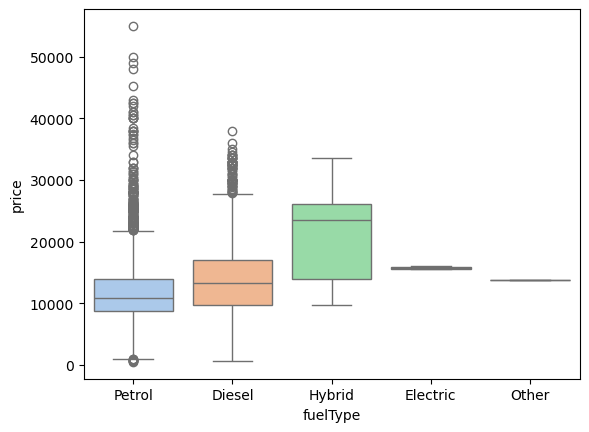

In [19]:
sns.boxplot( data = df , x = 'fuelType' , y = 'price' , palette = 'pastel' )

In [20]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

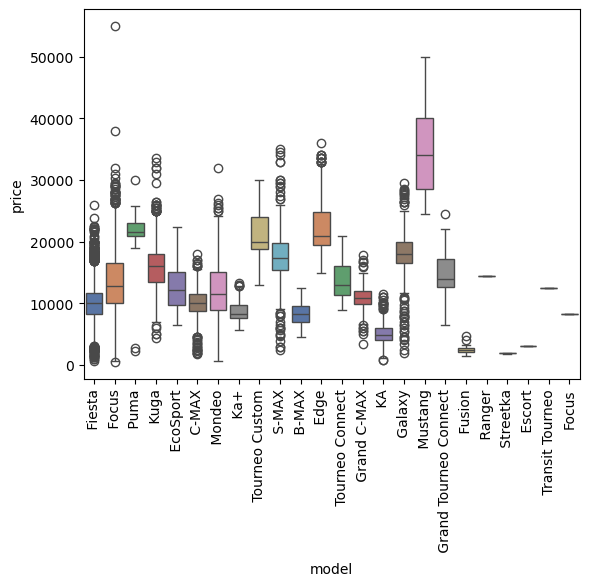

In [22]:
sns.boxplot( data = df , x = 'model' , y = 'price'  , palette = 'deep' )
plt.xticks(rotation = 90)

# MODEL CREATION 

In [26]:
X = df.drop(columns = 'price' , axis = 1)
y = df['price']

In [27]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [32]:
columns = ['model' , 'transmission' , 'fuelType']
X_one_encode = pd.get_dummies( X , columns)
X_one_encode = X_one_encode.astype('int')
X_one_encode.head()
# This was hot-one-encoding

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [37]:
from sklearn.preprocessing import LabelEncoder
columns = ['model' , 'transmission' , 'fuelType']
X_label = X.copy()
label_encoders = {}
for col in columns:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X_label[col].astype('string'))
    label_encoders[col] = le

    """
    ["Petrol", "Diesel", "Petrol", "Electric"]
        ↓  .astype('string')         # ensure clean strings
    ["Petrol", "Diesel", "Petrol", "Electric"]
        ↓  le.fit()                      # learns: Diesel=0, Electric=1, Petrol=2
        ↓  le.transform()                # applies the mapping
    [2, 0, 2, 1]                         # stored back into X_label[col]
    
    """

In [38]:
X_label

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [39]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [43]:
from sklearn.preprocessing import StandardScaler
# standardisation of the values in the numeric columns 
numeric_col = ['year', 'mileage',  'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X_one_encode[numeric_col] = scaler.fit_transform(X_one_encode[numeric_col])
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [46]:
numeric_cols = ['year', 'mileage',  'tax', 'mpg', 'engineSize' , 'model' , 'transmission' , 'fuelType']
scaler = StandardScaler()
X_label[numeric_cols] = scaler.fit_transform(X_label[numeric_cols])
X_label

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.33, random_state=42)

In [50]:

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:

y_pred = model.predict(X_test)

In [53]:

r2 = r2_score(y_test,y_pred)
r2

0.8401880779365885

In [54]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.8391843364467996


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_label, y, test_size=0.33, random_state=42)

In [58]:
model2 = LinearRegression()
model2.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
y_pred = model2.predict(X_test)

In [60]:
r2 = r2_score(y_test,y_pred)
r2

0.7310215557391142

In [ ]:
""" It means that doing label encoding on a simple linear regression model is not beneficial as in LR it starst comparing the values mod 
  like Linear Regression computes something like:

  price = 3000 × fuelType + ...

  This literally implies Electric (1) is halfway between Diesel (0) and Petrol (2), and that Petrol has "twice the fuel effect" of Electric.
  That's nonsense — and it skews your model. """